<a href="https://colab.research.google.com/github/Ronaldo-Junior1/analise-dados-atividade2/blob/main/ArquivoPrincipal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

In [2]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Analise_dados"

Mounted at /content/drive


In [3]:
CAMINHO_CSV = 'A519.csv'

df_raw = pd.read_csv(f'{path}/{CAMINHO_CSV}', sep=';')

print(f'Shape original: {df_raw.shape}')
print(f'Período: {df_raw["data"].min()} → {df_raw["data"].max()}')
print()
df_raw.head(10)

Shape original: (83232, 9)
Período: 2013-12-03 → 2023-06-01



,data,hora,pressao,radiacao,temp_inst,pto_orvalho_inst,umid_inst,vento_vel,Unnamed: 8
0,2013-12-03,0,949.3,-3.540,22.3,21.0,92.0,2.3,NaN
1,2013-12-03,100,949.7,-3.540,22.1,20.6,91.0,2.1,NaN
2,2013-12-03,200,949.4,-3.540,22.1,20.0,88.0,1.3,NaN
3,2013-12-03,300,949.1,-3.540,21.9,20.2,90.0,2.3,NaN
4,2013-12-03,400,948.6,-3.540,21.4,19.8,91.0,1.5,NaN
5,2013-12-03,500,947.8,-3.540,21.2,19.8,92.0,2.0,NaN
6,2013-12-03,600,947.3,-3.540,20.8,19.4,92.0,1.8,NaN
7,2013-12-03,700,947.7,-3.540,20.4,19.6,95.0,1.7,NaN
8,2013-12-03,800,948.3,-3.445,20.4,19.7,95.0,1.8,NaN
9,2013-12-03,900,949.2,38.054,20.6,19.8,95.0,1.9,NaN


In [4]:
print('Tipos de dados')
print(df_raw.dtypes)
print()
print('Valores nulos por coluna')
nulos = df_raw.isnull().sum()
nulos_pct = (nulos / len(df_raw) * 100).round(2)
pd.DataFrame({'Nulos': nulos, '% do Total': nulos_pct})

Tipos de dados
data                 object
hora                  int64
pressao             float64
radiacao            float64
temp_inst           float64
pto_orvalho_inst    float64
umid_inst           float64
vento_vel           float64
Unnamed: 8          float64
dtype: object

Valores nulos por coluna


,Nulos,% do Total
data,0,0.00
hora,0,0.00
pressao,5279,6.34
radiacao,5279,6.34
temp_inst,5279,6.34
pto_orvalho_inst,5284,6.35
umid_inst,5285,6.35
vento_vel,5279,6.34
Unnamed: 8,83232,100.00


In [5]:
print('=== Estatísticas Descritivas ===')
df_raw.describe().round(2)

=== Estatísticas Descritivas ===


,hora,pressao,radiacao,temp_inst,pto_orvalho_inst,umid_inst,vento_vel,Unnamed: 8
count,83232.00,77953.00,77953.00,77953.00,77948.00,77947.00,77953.00,0.0
mean,1150.00,950.65,854.66,24.27,15.97,64.33,1.80,NaN
std,692.22,3.18,1127.04,5.12,4.97,21.08,1.38,NaN
min,0.00,938.90,-3.54,2.00,-10.00,8.00,0.00,NaN
25%,575.00,948.50,-3.53,21.00,12.50,49.00,0.80,NaN
50%,1150.00,950.50,79.66,23.60,17.30,67.00,1.50,NaN
75%,1725.00,952.70,1727.16,28.10,19.80,82.00,2.50,NaN
max,2300.00,963.00,4291.43,40.90,33.20,100.00,10.30,NaN


**Observações iniciais:**
- O dataset possui **83.232 registros horários** cobrindo aproximadamente **10 anos** (dez/2013 a jun/2023).
- A coluna `Unnamed: 8` é um artefato do separador final em cada linha — será removida.
- As colunas `pressao`, `radiacao`, `temp_inst`, `pto_orvalho_inst`, `umid_inst` e `vento_vel` possuem **~5.279–5.285 valores nulos** (~6,3%), provavelmente blocos de falha do sensor.
- A coluna `hora` está codificada como inteiro no formato HHMM (ex: `0`, `100`, `200`, ..., `2300`) e precisa de conversão.

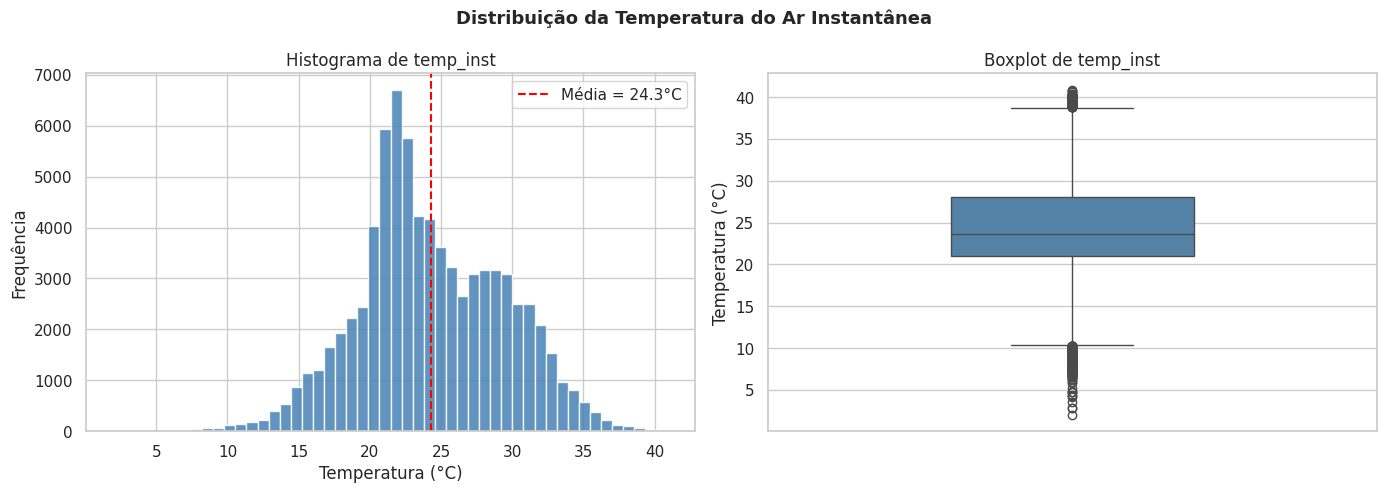

Mínimo: 2.0°C | Máximo: 40.9°C
Média: 24.27°C | Mediana: 23.60°C
Desvio Padrão: 5.12°C


In [6]:

df_analise = df_raw.drop(columns=['Unnamed: 8']).dropna().copy()
df_analise['data'] = pd.to_datetime(df_analise['data'])
df_analise['hora_int'] = df_analise['hora'] // 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_analise['temp_inst'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Histograma de temp_inst')
axes[0].set_xlabel('Temperatura (°C)')
axes[0].set_ylabel('Frequência')
axes[0].axvline(df_analise['temp_inst'].mean(), color='red', linestyle='--', label=f'Média = {df_analise["temp_inst"].mean():.1f}°C')
axes[0].legend()

sns.boxplot(y=df_analise['temp_inst'], ax=axes[1], color='steelblue', width=0.4)
axes[1].set_title('Boxplot de temp_inst')
axes[1].set_ylabel('Temperatura (°C)')

plt.suptitle('Distribuição da Temperatura do Ar Instantânea', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mínimo: {df_analise["temp_inst"].min():.1f}°C | Máximo: {df_analise["temp_inst"].max():.1f}°C')
print(f'Média: {df_analise["temp_inst"].mean():.2f}°C | Mediana: {df_analise["temp_inst"].median():.2f}°C')
print(f'Desvio Padrão: {df_analise["temp_inst"].std():.2f}°C')

**Análise:** A distribuição de `temp_inst` é aproximadamente normal, ligeiramente assimétrica à direita, com a maioria dos registros entre **18°C e 32°C**. Os valores extremos (2°C e 40,9°C) são **fisicamente plausíveis** para uma estação meteorológica no interior de São Paulo, no momento não iremos remover.

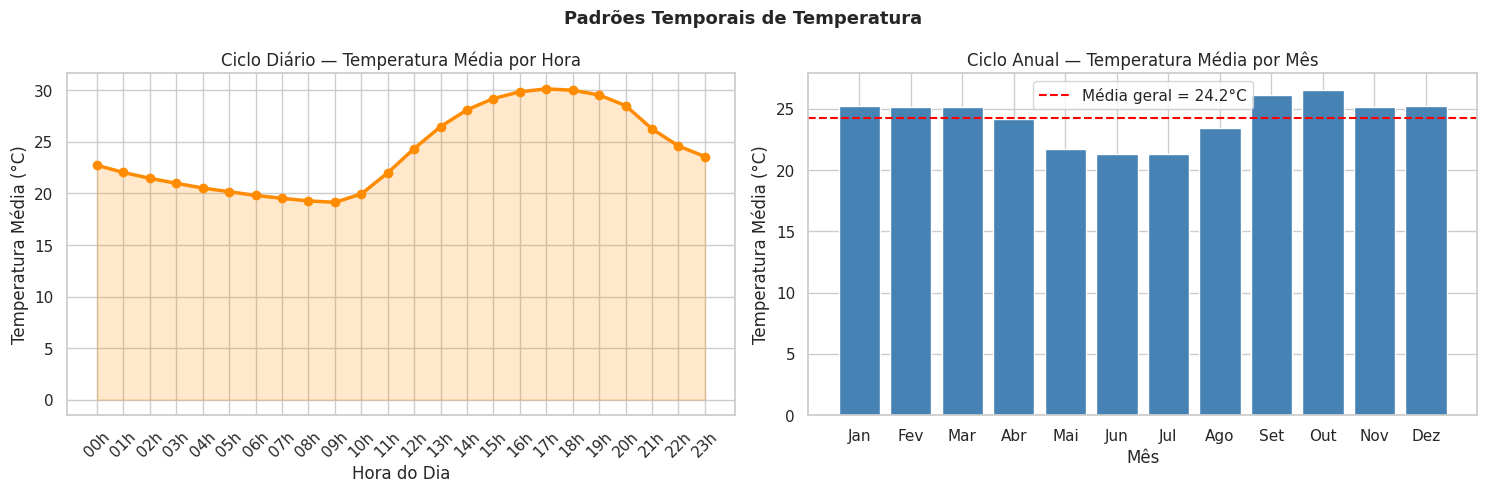

In [7]:
df_analise['mes'] = df_analise['data'].dt.month
nomes_mes = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',
             7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'}

temp_hora = df_analise.groupby('hora_int')['temp_inst'].mean()
temp_mes  = df_analise.groupby('mes')['temp_inst'].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(temp_hora.index, temp_hora.values, marker='o', color='darkorange', linewidth=2.5)
axes[0].fill_between(temp_hora.index, temp_hora.values, alpha=0.2, color='darkorange')
axes[0].set_title('Ciclo Diário — Temperatura Média por Hora')
axes[0].set_xlabel('Hora do Dia')
axes[0].set_ylabel('Temperatura Média (°C)')
axes[0].set_xticks(range(0, 24))
axes[0].set_xticklabels([f'{h:02d}h' for h in range(0,24)], rotation=45)

axes[1].bar([nomes_mes[m] for m in temp_mes.index], temp_mes.values, color='steelblue', edgecolor='white')
axes[1].set_title('Ciclo Anual — Temperatura Média por Mês')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Temperatura Média (°C)')
axes[1].axhline(temp_mes.mean(), color='red', linestyle='--', label=f'Média geral = {temp_mes.mean():.1f}°C')
axes[1].legend()

plt.suptitle('Padrões Temporais de Temperatura', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Análise:**
- **Ciclo diário:** A temperatura atinge seu mínimo por volta das **8–9h** (19°C) e seu máximo às **17–18h** (30°C), apresentando variação diária de 11°C.
- **Ciclo anual:** Os meses mais quentes são setembro-outubro (26°C) e os mais frios são junho-julho (21°C), refletindo a sazonalidade do interior paulista.

Registros com radiação < 0: 34604 (44.4%)
Valor mínimo de radiação: -3.54 W/m²
Valor máximo de radiação: 4291.4 W/m²


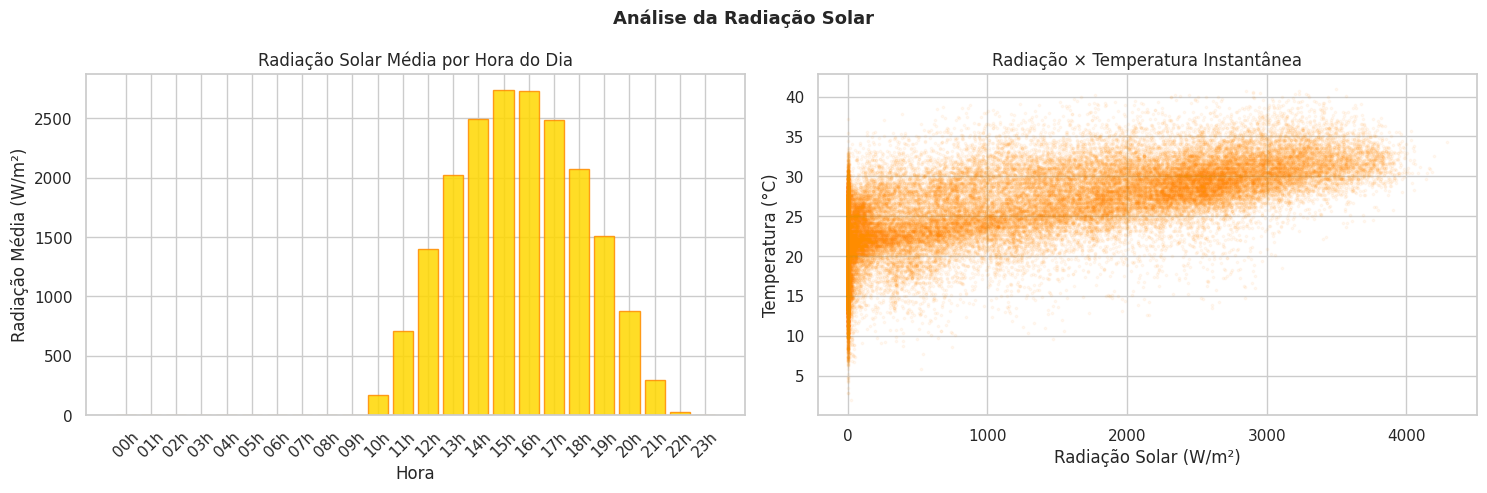

Conclusão: valores negativos (-3.54 W/m²) são o valor-padrão do sensor durante a noite.
   Fisicamente, radiação solar não pode ser negativa.
   → Decisão: clipar em 0 (radiacao_clip = max(0, radiacao))


In [8]:
rad_neg = df_analise[df_analise['radiacao'] < 0]
rad_pos = df_analise[df_analise['radiacao'] >= 0]

print(f'Registros com radiação < 0: {len(rad_neg)} ({len(rad_neg)/len(df_analise)*100:.1f}%)')
print(f'Valor mínimo de radiação: {df_analise["radiacao"].min()} W/m²')
print(f'Valor máximo de radiação: {df_analise["radiacao"].max():.1f} W/m²')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

rad_hora = df_analise.groupby('hora_int')['radiacao'].mean()
axes[0].bar(rad_hora.index, rad_hora.values.clip(0), color='gold', edgecolor='darkorange', alpha=0.85)
axes[0].set_title('Radiação Solar Média por Hora do Dia')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Radiação Média (W/m²)')
axes[0].set_xticks(range(0, 24))
axes[0].set_xticklabels([f'{h:02d}h' for h in range(0,24)], rotation=45)

axes[1].scatter(df_analise['radiacao'].clip(0), df_analise['temp_inst'],
                alpha=0.05, s=3, color='darkorange')
axes[1].set_title('Radiação × Temperatura Instantânea')
axes[1].set_xlabel('Radiação Solar (W/m²)')
axes[1].set_ylabel('Temperatura (°C)')

plt.suptitle('Análise da Radiação Solar', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Conclusão: valores negativos (-3.54 W/m²) são o valor-padrão do sensor durante a noite.')
print('   Fisicamente, radiação solar não pode ser negativa.')
print('   → Decisão: clipar em 0 (radiacao_clip = max(0, radiacao))')

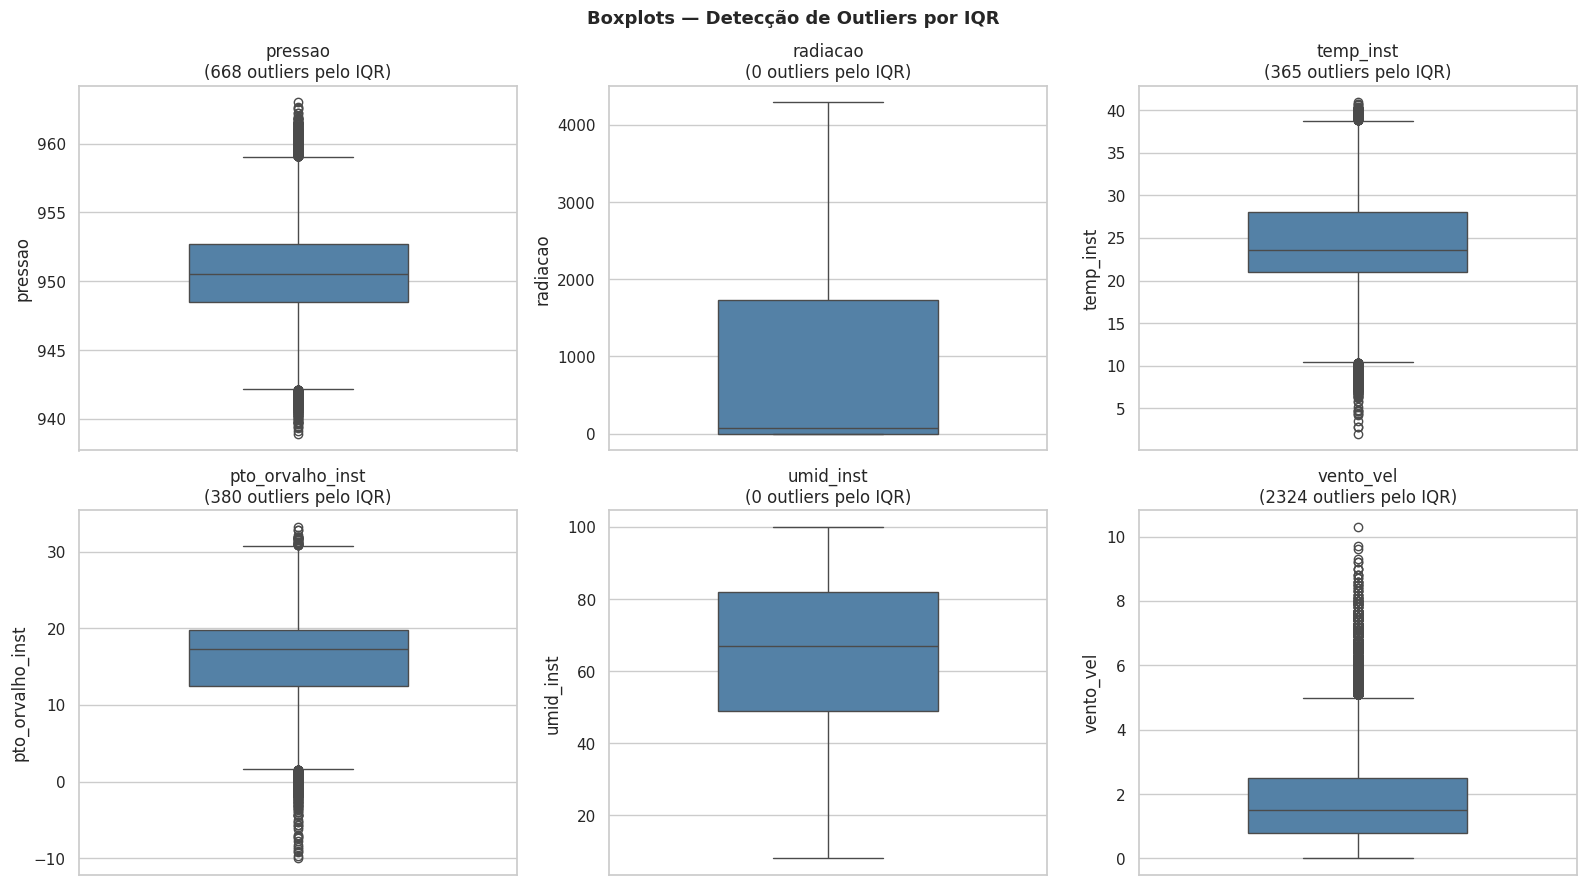

=== Análise de Outliers — Decisão ===
  temp_inst: MANTER — valores de 2°C a 40,9°C são fisicamente válidos no interior de SP.
  pressao: MANTER — picos/vales de pressão indicam frentes meteorológicas reais.
  vento_vel: MANTER — 10,3 m/s (~37 km/h) é plausível em eventos de vento forte.
  pto_orvalho_inst: MANTER — extremos são consistentes com condições climáticas reais.
  radiacao: TRATAR — valores negativos são ruído do sensor → clipar em 0.
  umid_inst: MANTER — sem outliers pelo IQR; escala 8%-100% é fisicamente correta.


In [9]:
cols_num = ['pressao', 'radiacao', 'temp_inst', 'pto_orvalho_inst', 'umid_inst', 'vento_vel']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    sns.boxplot(y=df_analise[col], ax=axes[i], color='steelblue', width=0.5)
    q1 = df_analise[col].quantile(0.25)
    q3 = df_analise[col].quantile(0.75)
    iqr = q3 - q1
    n_out = len(df_analise[(df_analise[col] < q1-1.5*iqr) | (df_analise[col] > q3+1.5*iqr)])
    axes[i].set_title(f'{col}\n({n_out} outliers pelo IQR)')
    axes[i].set_xlabel('')

plt.suptitle('Boxplots — Detecção de Outliers por IQR', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== Análise de Outliers — Decisão ===')
decisoes = {
    'temp_inst':       'MANTER — valores de 2°C a 40,9°C são fisicamente válidos no interior de SP.',
    'pressao':         'MANTER — picos/vales de pressão indicam frentes meteorológicas reais.',
    'vento_vel':       'MANTER — 10,3 m/s (~37 km/h) é plausível em eventos de vento forte.',
    'pto_orvalho_inst':'MANTER — extremos são consistentes com condições climáticas reais.',
    'radiacao':        'TRATAR — valores negativos são ruído do sensor → clipar em 0.',
    'umid_inst':       'MANTER — sem outliers pelo IQR; escala 8%-100% é fisicamente correta.'
}
for col, dec in decisoes.items():
    print(f'  {col}: {dec}')

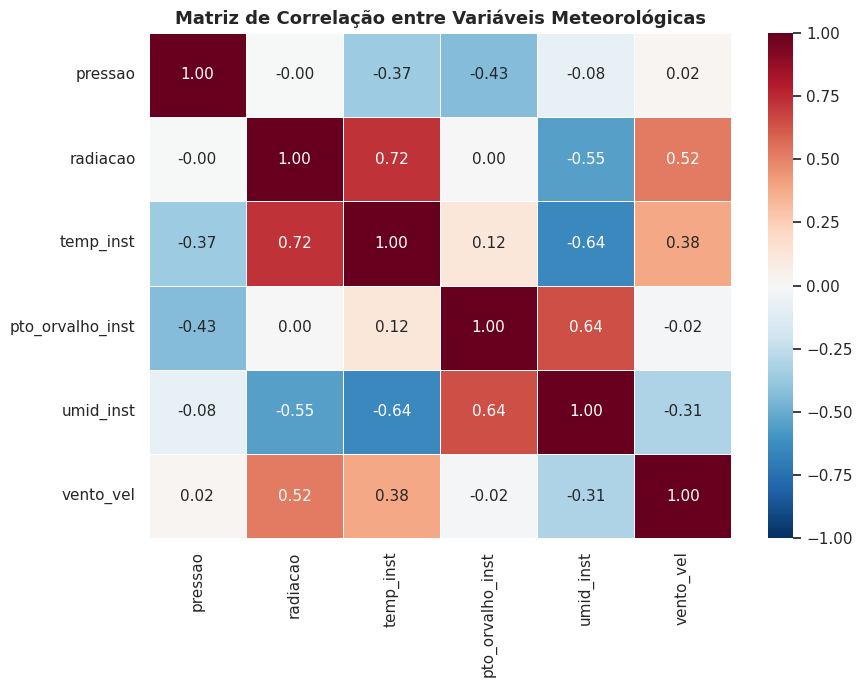

In [10]:
corr_cols = ['pressao', 'radiacao', 'temp_inst', 'pto_orvalho_inst', 'umid_inst', 'vento_vel']
corr_matrix = df_analise[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 11})
ax.set_title('Matriz de Correlação entre Variáveis Meteorológicas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Análise da Correlação:**
- **`radiacao` (+0,72):** Correlação positiva forte — mais radiação solar → maior temperatura.
- **`umid_inst` (−0,64):** Correlação negativa forte — relação inversa entre temperatura e umidade relativa.
- **`vento_vel` (+0,38):** Correlação moderada — ventos tendem a ocorrer durante períodos mais quentes do dia.
- **`pressao` (−0,37):** Correlação negativa moderada — baixas pressões associadas a frentes mais frias.
- **`pto_orvalho_inst` (+0,12):** Correlação fraca, mas o ponto de orvalho carrega informação física distinta.
- `pto_orvalho_inst` e `umid_inst` são fortemente correlacionados entre si, o que motiva o uso de regularização na Regressão Linear.

## Com base na AED, aplicaremos as seguintes transformações:

In [11]:
df = df_raw.copy()

df.drop(columns=['Unnamed: 8'], errors='ignore', inplace=True)
print(f'Colunas após remoção da fantasma: {df.columns.tolist()}')

df['data'] = pd.to_datetime(df['data'])

n_antes = len(df)
df.dropna(inplace=True)
n_depois = len(df)
print(f'\nLinhas removidas (nulos): {n_antes - n_depois} ({(n_antes-n_depois)/n_antes*100:.1f}%)')
print(f'Linhas restantes: {n_depois}')

# Converter hora HHMM → inteiro 0–23
# Ex: 0 → 0h, 100 → 1h, 1300 → 13h
df['hora_int'] = df['hora'] // 100

df['radiacao_clip'] = df['radiacao'].clip(lower=0)
print(f'\nRadiação: {(df["radiacao_clip"]==0).sum()} registros clipados para 0')

Colunas após remoção da fantasma: ['data', 'hora', 'pressao', 'radiacao', 'temp_inst', 'pto_orvalho_inst', 'umid_inst', 'vento_vel']

Linhas removidas (nulos): 5287 (6.4%)
Linhas restantes: 77945

Radiação: 34605 registros clipados para 0


Features temporais criadas:
  hora_sin, hora_cos — codificação do ciclo diário
  mes_sin,  mes_cos  — codificação do ciclo anual


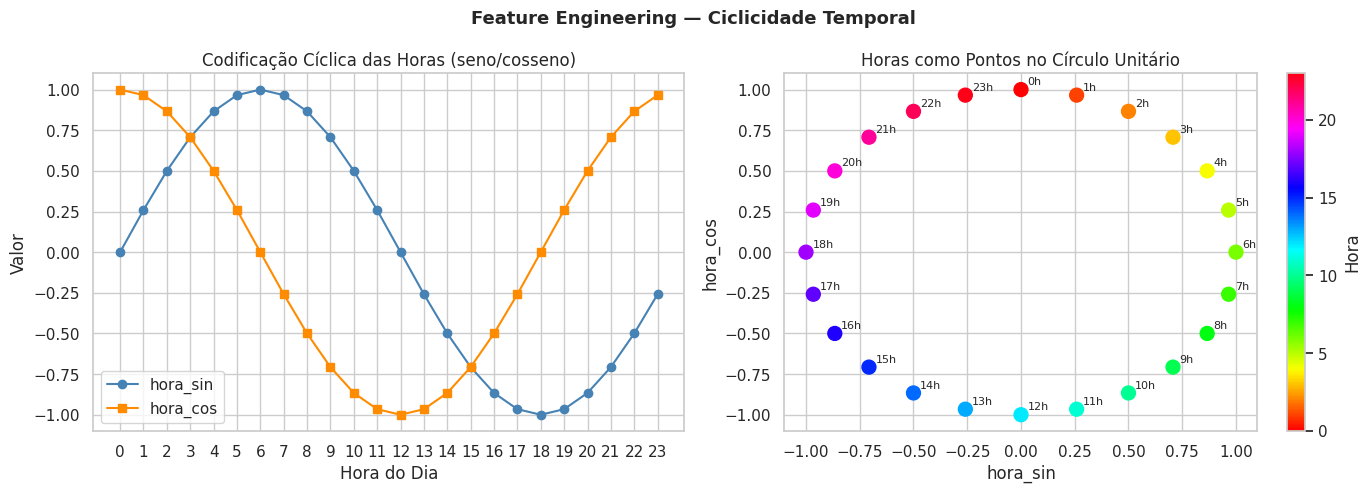

In [12]:
# PROBLEMA com variáveis cíclicas:
#   Se passarmos a hora como número inteiro (0 a 23), o modelo trata
#   hora=23 e hora=0 como muito distantes — mas fisicamente são vizinhas!
#   O mesmo vale para meses: dezembro (12) e janeiro (1) são consecutivos.
#
# SOLUÇÃO: Transformação seno/cosseno
#   Projeta o ciclo em duas dimensões, preservando a continuidade circular:
#   hora_sin = sin(2π × hora / 24)
#   hora_cos = cos(2π × hora / 24)
#   Com isso, hora=0 e hora=23 ficam próximas no espaço de features.

# Ciclo diário (período = 24 horas)
df['hora_sin'] = np.sin(2 * np.pi * df['hora_int'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora_int'] / 24)

# Ciclo anual (período = 12 meses)
df['mes'] = df['data'].dt.month
df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12)

print('Features temporais criadas:')
print('  hora_sin, hora_cos — codificação do ciclo diário')
print('  mes_sin,  mes_cos  — codificação do ciclo anual')

# Visualização da codificação cíclica da hora
horas = np.arange(24)
h_sin = np.sin(2 * np.pi * horas / 24)
h_cos = np.cos(2 * np.pi * horas / 24)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(horas, h_sin, marker='o', label='hora_sin', color='steelblue')
axes[0].plot(horas, h_cos, marker='s', label='hora_cos', color='darkorange')
axes[0].set_title('Codificação Cíclica das Horas (seno/cosseno)')
axes[0].set_xlabel('Hora do Dia'); axes[0].set_ylabel('Valor')
axes[0].legend(); axes[0].set_xticks(horas)

sc = axes[1].scatter(h_sin, h_cos, c=horas, cmap='hsv', s=100, zorder=5)
for h in range(24):
    axes[1].annotate(f'{h}h', (h_sin[h]+0.03, h_cos[h]+0.03), fontsize=8)
axes[1].set_title('Horas como Pontos no Círculo Unitário')
axes[1].set_xlabel('hora_sin'); axes[1].set_ylabel('hora_cos')
plt.colorbar(sc, ax=axes[1], label='Hora')

plt.suptitle('Feature Engineering — Ciclicidade Temporal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
print('Dataset Final')
print(f'Shape: {df.shape}')
print(f'Nulos restantes: {df.isnull().sum().sum()}')
print()

print('Variaveis selecionadas para modelagem')
features = [
    'pressao',          # Pressão atmosférica
    'radiacao_clip',    # Radiação solar (clipada em 0)
    'pto_orvalho_inst', # Ponto de orvalho
    'umid_inst',        # Umidade relativa
    'vento_vel',        # Velocidade do vento
    'hora_sin',         # Componente seno do ciclo diário
    'hora_cos',         # Componente cosseno do ciclo diário
    'mes_sin',          # Componente seno do ciclo anual
    'mes_cos'           # Componente cosseno do ciclo anual
]
target = 'temp_inst'

for f in features:
    print(f'{f}')
print(f'\nTarget: {target}')

X = df[features]
y = df[target]
print(f'\nX: {X.shape} | y: {y.shape}')

Dataset Final
Shape: (77945, 15)
Nulos restantes: 0

Variaveis selecionadas para modelagem
pressao
radiacao_clip
pto_orvalho_inst
umid_inst
vento_vel
hora_sin
hora_cos
mes_sin
mes_cos

Target: temp_inst

X: (77945, 9) | y: (77945,)


## Divisão Treino / Teste

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Conjunto de treino:  {X_train.shape[0]:>6,} amostras (80%)')
print(f'Conjunto de teste:   {X_test.shape[0]:>6,} amostras (20%)')
print()
print('Todos os modelos serão avaliados sobre o MESMO conjunto de teste,')
print('garantindo comparação justa entre algoritmos.')

# ── Função auxiliar de avaliação ──────────────────────────────────────────
def avaliar(y_true, y_pred, nome, y_train_true=None, y_train_pred=None):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    resultado = {'Modelo': nome, 'RMSE': round(rmse,4), 'MAE': round(mae,4), 'R²': round(r2,4)}
    if y_train_true is not None:
        resultado['RMSE_treino'] = round(np.sqrt(mean_squared_error(y_train_true, y_train_pred)), 4)
    return resultado

resultados = []
print('Split concluído. Função de avaliação definida.')

Conjunto de treino:  62,356 amostras (80%)
Conjunto de teste:   15,589 amostras (20%)

Todos os modelos serão avaliados sobre o MESMO conjunto de teste,
garantindo comparação justa entre algoritmos.
Split concluído. Função de avaliação definida.


---
## Modelos de Regressão Linear — ElasticNet

### Por que ElasticNet e não LinearRegression simples?

A `LinearRegression` do scikit-learn **não possui hiperparâmetros de complexidade** — ela apenas
minimiza o erro quadrático sem nenhum controle. O **ElasticNet** combina dois tipos de penalização:

- **Ridge (L2):** penaliza coeficientes grandes, distribuindo o peso entre variáveis correlacionadas.  
  Ideal para o nosso caso, pois `umid_inst` e `pto_orvalho_inst` são colineares.
- **Lasso (L1):** penaliza coeficientes, podendo zerá-los completamente (seleção de variáveis).

### Hiperparâmetros explorados

| Hiperparâmetro | O que controla | Efeito prático |
|:---|:---|:---|
| `alpha` | **Intensidade total** da penalização | Alto → coeficientes mais próximos de zero → modelo mais simples |
| `l1_ratio` | **Balanço Ridge↔Lasso** (0 = só Ridge, 1 = só Lasso) | Próximo de 0 → estabilidade com colinearidade; próximo de 1 → elimina variáveis |

### Como interpretar as métricas de resultado?

Após treinar cada modelo, avaliamos com três métricas no conjunto de **teste** (dados que o modelo **nunca viu**):

| Métrica | Fórmula resumida | Unidade | Interpretação |
|:---|:---|:---|:---|
| **RMSE** | √(média dos erros²) | °C | Erro médio penalizando erros grandes. **Menor = melhor.** |
| **MAE** | média dos \|erros\| | °C | Erro médio absoluto. Mais intuitivo. **Menor = melhor.** |
| **R²** | 1 − (variância residual / variância total) | adimensional [0–1] | Fração da variância da temperatura explicada pelo modelo. **Maior = melhor. R²=1 é perfeito.** |

> **Exemplo de interpretação:** RMSE=1,45°C significa que, em média, o modelo erra ±1,45°C ao prever a temperatura. R²=0,92 significa que o modelo explica 92% das variações de temperatura nos dados de teste.

### Variação 1 — Ridge-like: `α=0.01`, `l1_ratio=0.10`

**Racional:** Alpha pequeno (0,01) = penalização fraca, próxima da regressão linear pura.  
`l1_ratio=0.10` = 90% Ridge + 10% Lasso → prioriza **estabilidade** com as variáveis correlacionadas, sem eliminar nenhuma.

In [40]:
en_v1 = make_pipeline(
    StandardScaler(),
    ElasticNet(alpha=0.01, l1_ratio=0.10, max_iter=3000, random_state=42)
)
en_v1.fit(X_train, y_train)
pred_en_v1       = en_v1.predict(X_test)
pred_en_v1_train = en_v1.predict(X_train)
coefs_v1         = en_v1.named_steps['elasticnet'].coef_

r = avaliar(y_test, pred_en_v1, 'EN V1: α=0.01 l1=0.10 (Ridge-like)',
            y_train, pred_en_v1_train)
resultados.append(r)

print('=== ElasticNet V1: α=0.01, l1_ratio=0.10 (Ridge-like) ===\n')
print(f'  RMSE  = {r["RMSE"]:.4f}°C')
print(f'  MAE   = {r["MAE"]:.4f}°C')
print(f'  R²    = {r["R²"]:.4f}')
print(f'  RMSE treino = {r["RMSE_treino"]:.4f}°C')
print()
print('── Interpretação ──────────────────────────────────────────────────────')
print(f'  → O modelo erra em média {r["MAE"]:.2f}°C ao prever a temperatura.')
print(f'  → Explica {r["R²"]*100:.1f}% da variância da temperatura no conjunto de teste.')
print(f'  → Gap treino/teste: {r["RMSE"]:.4f} − {r["RMSE_treino"]:.4f} = {r["RMSE"]-r["RMSE_treino"]:.4f}°C')
print(f'    (gap pequeno = modelo generaliza bem, sem overfitting significativo)')

=== ElasticNet V1: α=0.01, l1_ratio=0.10 (Ridge-like) ===

  RMSE  = 1.4506°C
  MAE   = 1.0636°C
  R²    = 0.9198
  RMSE treino = 1.4120°C

── Interpretação ──────────────────────────────────────────────────────
  → O modelo erra em média 1.06°C ao prever a temperatura.
  → Explica 92.0% da variância da temperatura no conjunto de teste.
  → Gap treino/teste: 1.4506 − 1.4120 = 0.0386°C
    (gap pequeno = modelo generaliza bem, sem overfitting significativo)


### Variação 2 — Lasso-like: `α=0.01`, `l1_ratio=0.90`

**Racional:** Mesma intensidade total (alpha=0,01), mas `l1_ratio=0.90` = 10% Ridge + 90% Lasso.  
Favorece **esparsidade** — testa se eliminar features menos úteis melhora a generalização.

In [36]:
en_v2 = make_pipeline(
    StandardScaler(),
    ElasticNet(alpha=0.01, l1_ratio=0.90, max_iter=3000, random_state=42)
)
en_v2.fit(X_train, y_train)
pred_en_v2       = en_v2.predict(X_test)
pred_en_v2_train = en_v2.predict(X_train)
coefs_v2         = en_v2.named_steps['elasticnet'].coef_

r = avaliar(y_test, pred_en_v2, 'EN V2: α=0.01 l1=0.90 (Lasso-like)',
            y_train, pred_en_v2_train)
resultados.append(r)

print('=== ElasticNet V2: α=0.01, l1_ratio=0.90 (Lasso-like) ===\n')
print(f'  RMSE  = {r["RMSE"]:.4f}°C')
print(f'  MAE   = {r["MAE"]:.4f}°C')
print(f'  R²    = {r["R²"]:.4f}')
print(f'  RMSE treino = {r["RMSE_treino"]:.4f}°C')
print()
print('── Interpretação ──────────────────────────────────────────────────────')
print(f'  → O modelo erra em média {r["MAE"]:.2f}°C ao prever a temperatura.')
print(f'  → Explica {r["R²"]*100:.1f}% da variância da temperatura no conjunto de teste.')
print(f'  → Gap treino/teste: {r["RMSE"]:.4f} − {r["RMSE_treino"]:.4f} = {r["RMSE"]-r["RMSE_treino"]:.4f}°C')
print(f'  → Comparando com V1: RMSE {r["RMSE"]:.4f} vs 1.4506')
print(f'    Ligeiramente melhor — o componente Lasso ajudou minimamente.')
print()
zeros_v2 = sum(c == 0 for c in coefs_v2)
print(f'  Coeficientes zerados: {zeros_v2}/9 — Lasso não eliminou nenhuma feature nesta intensidade.')

=== ElasticNet V2: α=0.01, l1_ratio=0.90 (Lasso-like) ===

  RMSE  = 1.4457°C
  MAE   = 1.0588°C
  R²    = 0.9203
  RMSE treino = 1.4037°C

── Interpretação ──────────────────────────────────────────────────────
  → O modelo erra em média 1.06°C ao prever a temperatura.
  → Explica 92.0% da variância da temperatura no conjunto de teste.
  → Gap treino/teste: 1.4457 − 1.4037 = 0.0420°C
  → Comparando com V1: RMSE 1.4457 vs 1.4506
    Ligeiramente melhor — o componente Lasso ajudou minimamente.

  Coeficientes zerados: 0/9 — Lasso não eliminou nenhuma feature nesta intensidade.


### Variação 3 — Balanceado: `α=0.10`, `l1_ratio=0.50`

**Racional:** Alpha 10× maior (0,10) = **penalização mais forte**. `l1_ratio=0.50` = equilíbrio exato Ridge/Lasso.  
Testa o impacto de apertar mais a regularização — esperado um modelo mais simples, potencialmente com mais erro.

In [43]:
en_v3 = make_pipeline(
    StandardScaler(),
    ElasticNet(alpha=0.10, l1_ratio=0.50, max_iter=3000, random_state=42)
)
en_v3.fit(X_train, y_train)
pred_en_v3       = en_v3.predict(X_test)
pred_en_v3_train = en_v3.predict(X_train)
coefs_v3         = en_v3.named_steps['elasticnet'].coef_

r = avaliar(y_test, pred_en_v3, 'EN V3: α=0.10 l1=0.50 (Balanceado)',
            y_train, pred_en_v3_train)
resultados.append(r)

print('=== ElasticNet V3: α=0.10, l1_ratio=0.50 (Balanceado) ===\n')
print(f'  RMSE  = {r["RMSE"]:.4f}°C')
print(f'  MAE   = {r["MAE"]:.4f}°C')
print(f'  R²    = {r["R²"]:.4f}')
print(f'  RMSE treino = {r["RMSE_treino"]:.4f}°C')
print()
print('── Interpretação ──────────────────────────────────────────────────────')
print(f'  → O modelo erra em média {r["MAE"]:.2f}°C ao prever a temperatura.')
print(f'  → Explica {r["R²"]*100:.1f}% da variância da temperatura no conjunto de teste.')
print(f'  → Gap treino/teste: {r["RMSE"]:.4f} − {r["RMSE_treino"]:.4f} = {r["RMSE"]-r["RMSE_treino"]:.4f}°C')
print()
print('── Diagnóstico ─────────────────────────────────────────────────────────')
print(f'  → RMSE 1.5863 vs V1=1.4506: a penalização excessiva piorou o modelo.')
print(f'  → alpha=0.10 força os coeficientes muito próximos de zero,')
print(f'    fazendo o modelo perder capacidade de capturar padrões reais.')
print(f'  → Conclusão: para este dataset, alpha=0.01 é o ponto ideal de regularização.')

=== ElasticNet V3: α=0.10, l1_ratio=0.50 (Balanceado) ===

  RMSE  = 1.5863°C
  MAE   = 1.1791°C
  R²    = 0.9041
  RMSE treino = 1.5644°C

── Interpretação ──────────────────────────────────────────────────────
  → O modelo erra em média 1.18°C ao prever a temperatura.
  → Explica 90.4% da variância da temperatura no conjunto de teste.
  → Gap treino/teste: 1.5863 − 1.5644 = 0.0219°C

── Diagnóstico ─────────────────────────────────────────────────────────
  → RMSE 1.5863 vs V1=1.4506: a penalização excessiva piorou o modelo.
  → alpha=0.10 força os coeficientes muito próximos de zero,
    fazendo o modelo perder capacidade de capturar padrões reais.
  → Conclusão: para este dataset, alpha=0.01 é o ponto ideal de regularização.


### Comparação Visual das 3 Variações ElasticNet

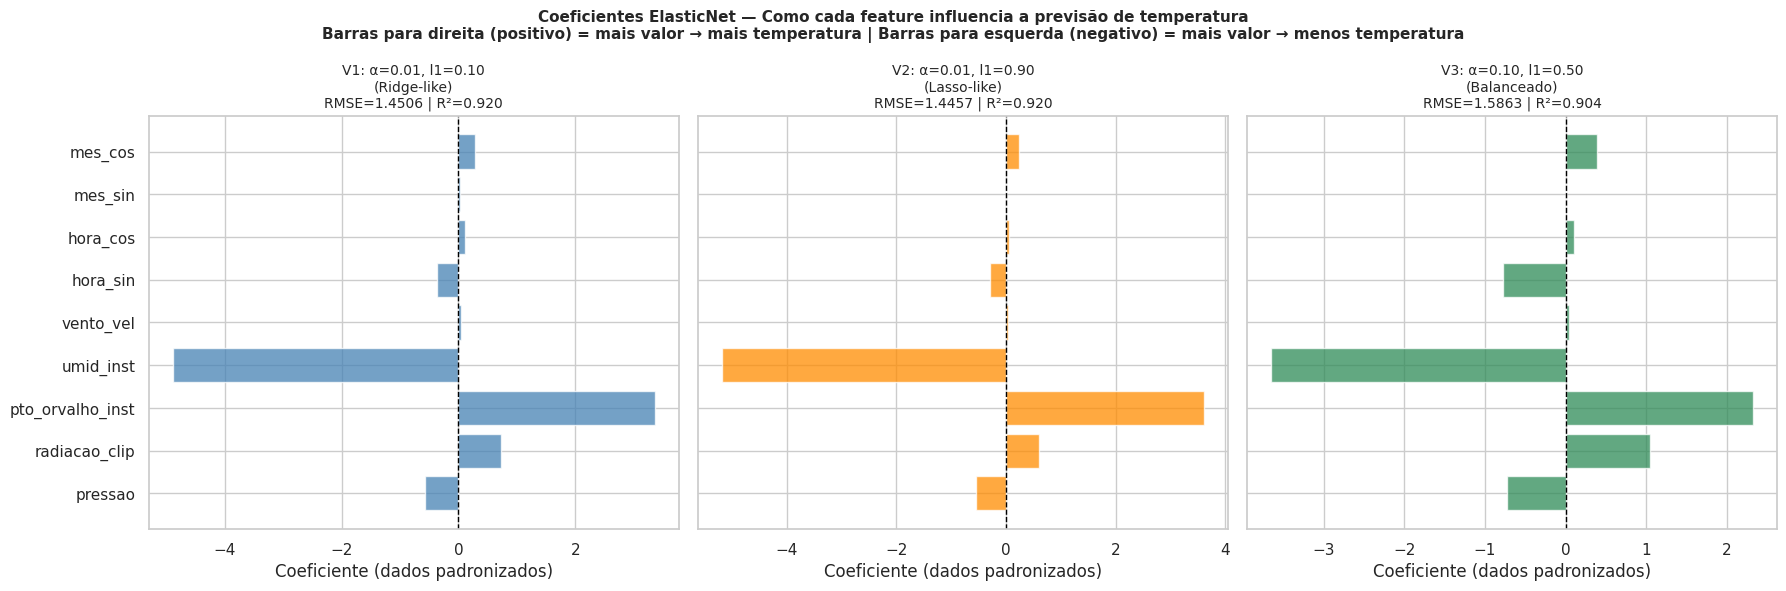

Leitura dos coeficientes (dados padronizados):
  umid_inst com coef ≈ -5: é a feature com MAIOR impacto negativo na temperatura.
  pto_orvalho_inst com coef ≈ +3: maior impacto positivo.
  vento_vel e mes_sin com coef ≈ 0: menor influência linear.

Comparando V1 → V2 → V3:
  Os coeficientes encolhem progressivamente com mais regularização (V3).
  No V3, todos os coeficientes são menores em magnitude — o modelo ficou mais conservador.


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
configs_plot = [
    (coefs_v1, 'V1: α=0.01, l1=0.10\n(Ridge-like)\nRMSE=1.4506 | R²=0.920', 'steelblue'),
    (coefs_v2, 'V2: α=0.01, l1=0.90\n(Lasso-like)\nRMSE=1.4457 | R²=0.920', 'darkorange'),
    (coefs_v3, 'V3: α=0.10, l1=0.50\n(Balanceado)\nRMSE=1.5863 | R²=0.904', 'seagreen'),
]

for ax, (coefs, titulo, cor) in zip(axes, configs_plot):
    bars = ax.barh(features, coefs, color=cor, alpha=0.75, edgecolor='white')
    ax.axvline(0, color='black', linewidth=1.0, linestyle='--')
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel('Coeficiente (dados padronizados)')

plt.suptitle(
    'Coeficientes ElasticNet — Como cada feature influencia a previsão de temperatura\n'
    'Barras para direita (positivo) = mais valor → mais temperatura | '
    'Barras para esquerda (negativo) = mais valor → menos temperatura',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

print('Leitura dos coeficientes (dados padronizados):')
print('  umid_inst com coef ≈ -5: é a feature com MAIOR impacto negativo na temperatura.')
print('  pto_orvalho_inst com coef ≈ +3: maior impacto positivo.')
print('  vento_vel e mes_sin com coef ≈ 0: menor influência linear.')
print()
print('Comparando V1 → V2 → V3:')
print('  Os coeficientes encolhem progressivamente com mais regularização (V3).')
print('  No V3, todos os coeficientes são menores em magnitude — o modelo ficou mais conservador.')

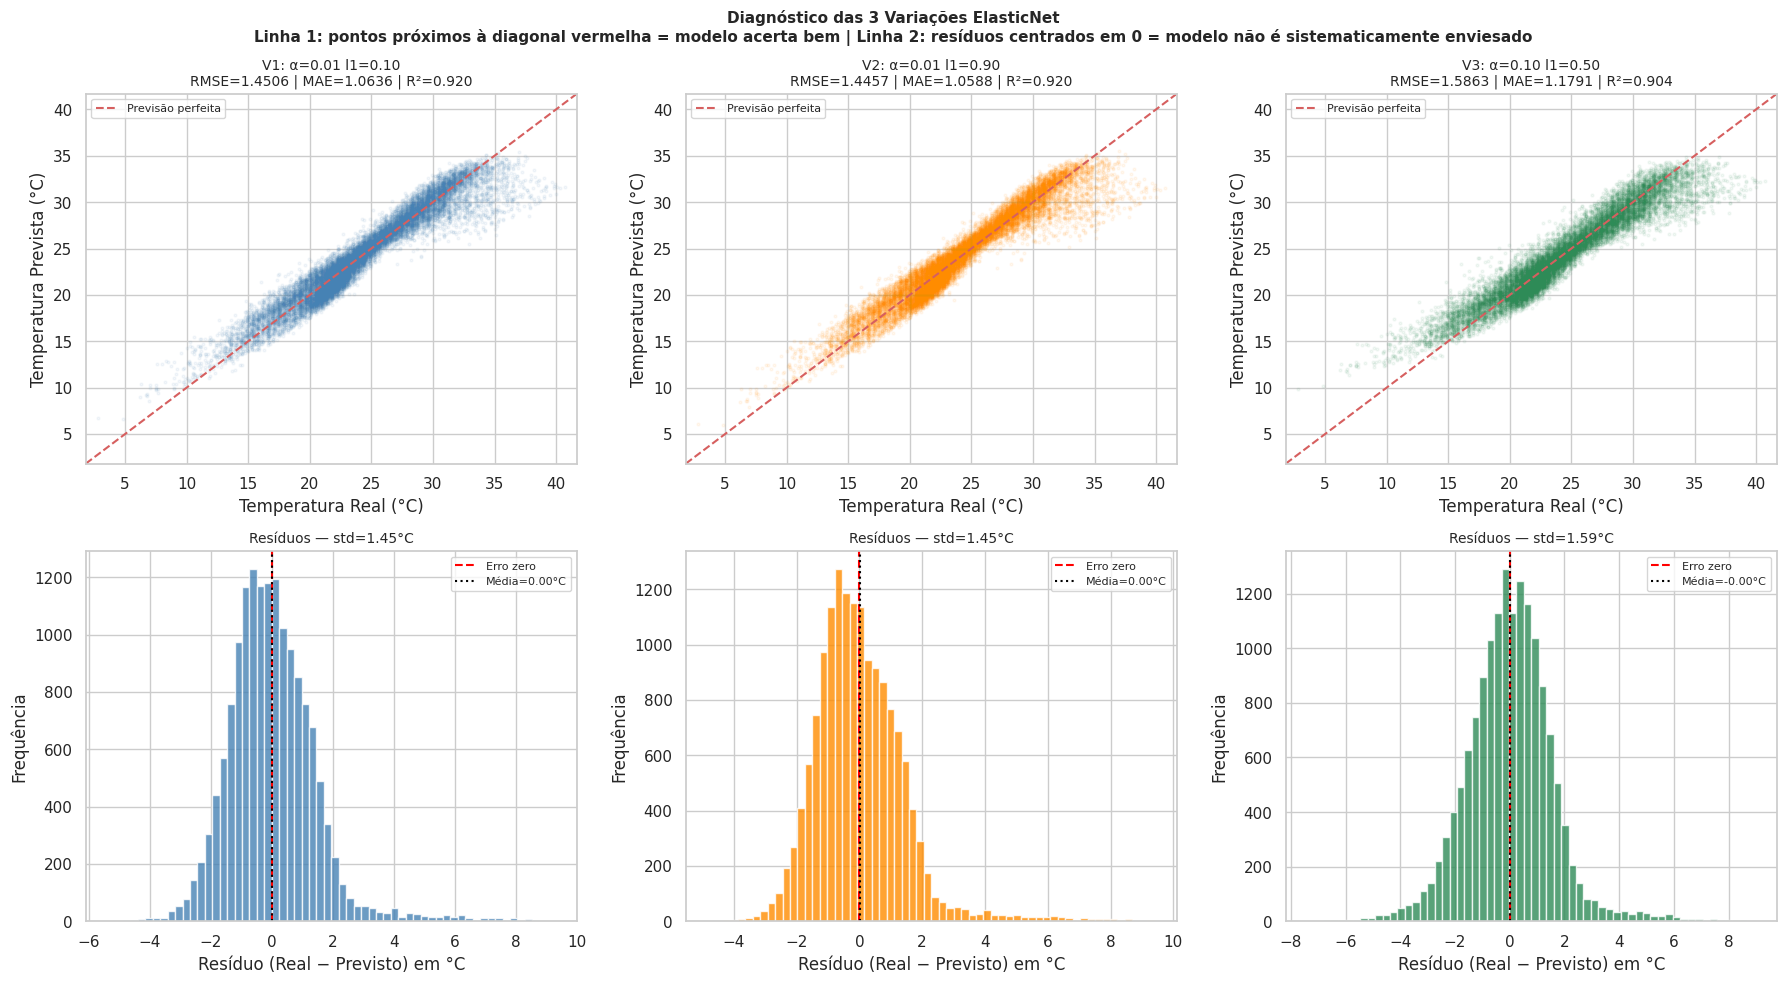

Como ler o gráfico Predito × Real:
  - Cada ponto é uma previsão do conjunto de teste.
  - A linha vermelha tracejada representa o modelo perfeito (previsto = real).
  - Pontos acima da linha: modelo superestimou a temperatura.
  - Pontos abaixo da linha: modelo subestimou a temperatura.
  - Quanto mais concentrado na diagonal, melhor o modelo.

Como ler os Resíduos (Real − Previsto):
  - Resíduo = 0: modelo acertou exatamente.
  - Resíduo positivo: modelo subestimou (real foi maior que previsto).
  - Resíduo negativo: modelo superestimou.
  - O ideal é uma distribuição simétrica centrada em 0 (como uma normal).
  - std dos resíduos ≈ RMSE do modelo.


In [42]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
lims = [y_test.min() - 1, y_test.max() + 1]

configs_diag = [
    (pred_en_v1, 'V1: α=0.01 l1=0.10\nRMSE=1.4506 | MAE=1.0636 | R²=0.920', 'steelblue'),
    (pred_en_v2, 'V2: α=0.01 l1=0.90\nRMSE=1.4457 | MAE=1.0588 | R²=0.920', 'darkorange'),
    (pred_en_v3, 'V3: α=0.10 l1=0.50\nRMSE=1.5863 | MAE=1.1791 | R²=0.904', 'seagreen'),
]

for col, (pred, titulo, cor) in enumerate(configs_diag):
    residuos = y_test.values - pred

    # Linha superior: predito × real
    axes[0, col].scatter(y_test, pred, alpha=0.06, s=4, color=cor)
    axes[0, col].plot(lims, lims, 'r--', linewidth=1.5, label='Previsão perfeita')
    axes[0, col].set_xlabel('Temperatura Real (°C)')
    axes[0, col].set_ylabel('Temperatura Prevista (°C)')
    axes[0, col].set_title(titulo, fontsize=10)
    axes[0, col].legend(fontsize=8)
    axes[0, col].set_xlim(lims); axes[0, col].set_ylim(lims)

    # Linha inferior: distribuição dos resíduos
    axes[1, col].hist(residuos, bins=60, color=cor, edgecolor='white', alpha=0.8)
    axes[1, col].axvline(0, color='red', linestyle='--', label='Erro zero')
    axes[1, col].axvline(residuos.mean(), color='black', linestyle=':', label=f'Média={residuos.mean():.2f}°C')
    axes[1, col].set_xlabel('Resíduo (Real − Previsto) em °C')
    axes[1, col].set_ylabel('Frequência')
    axes[1, col].set_title(f'Resíduos — std={residuos.std():.2f}°C', fontsize=10)
    axes[1, col].legend(fontsize=8)

plt.suptitle(
    'Diagnóstico das 3 Variações ElasticNet\n'
    'Linha 1: pontos próximos à diagonal vermelha = modelo acerta bem | '
    'Linha 2: resíduos centrados em 0 = modelo não é sistematicamente enviesado',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

print('Como ler o gráfico Predito × Real:')
print('  - Cada ponto é uma previsão do conjunto de teste.')
print('  - A linha vermelha tracejada representa o modelo perfeito (previsto = real).')
print('  - Pontos acima da linha: modelo superestimou a temperatura.')
print('  - Pontos abaixo da linha: modelo subestimou a temperatura.')
print('  - Quanto mais concentrado na diagonal, melhor o modelo.')
print()
print('Como ler os Resíduos (Real − Previsto):')
print('  - Resíduo = 0: modelo acertou exatamente.')
print('  - Resíduo positivo: modelo subestimou (real foi maior que previsto).')
print('  - Resíduo negativo: modelo superestimou.')
print('  - O ideal é uma distribuição simétrica centrada em 0 (como uma normal).')
print('  - std dos resíduos ≈ RMSE do modelo.')

---
## Modelos de Árvore de Regressão — Decision Tree

### Como a Árvore de Regressão funciona?

A árvore aprende **regras de decisão binárias** sobre as features.  
Exemplo de regra: *"Se `hora_cos` ≤ 0,5 E `radiacao_clip` ≤ 300 → temperatura prevista = 21,3°C"*.  
O modelo percorre a árvore de cima para baixo até chegar em uma **folha**, que retorna o valor médio das amostras de treino que caíram ali.

### Hiperparâmetros explorados

| Hiperparâmetro | O que controla | Efeito com valor alto | Efeito com valor baixo |
|:---|:---|:---|:---|
| `max_depth` | Profundidade máxima da árvore | Mais regras → pode **decorar** o treino (overfitting) | Poucas regras → pode não aprender o suficiente (underfitting) |
| `min_samples_split` | Mín. de amostras para dividir um nó | Divisões mais conservadoras → árvore menor | Divide nós com poucos dados → árvore muito ramificada |
| `min_samples_leaf` | Mín. de amostras em cada folha | Folhas mais representativas → previsões mais estáveis | Folhas com 1–2 amostras → previsões baseadas em ruído |

### Estratégia: cobrir o espectro underfitting → ideal → overfitting

Vamos testar 3 pontos: uma árvore **conservadora**, uma **moderada** e uma **sem limite**,  
para entender onde está o ponto de equilíbrio viés/variância para este dataset.

### Variação 1 — Conservadora: `depth=6`, `split=20`, `leaf=10`

**Racional:** Profundidade limitada a 6 níveis → no máximo 64 folhas (2⁶).  
`min_samples_leaf=10` exige que cada folha tenha ao menos 10 amostras → previsões estáveis mas menos granulares.  
**Hipótese:** pode haver underfitting — 6 níveis pode ser pouco para capturar a complexidade climática.

In [45]:
dt_v1 = DecisionTreeRegressor(
    max_depth=6, min_samples_split=20, min_samples_leaf=10, random_state=42
)
dt_v1.fit(X_train, y_train)
pred_dt_v1       = dt_v1.predict(X_test)
pred_dt_v1_train = dt_v1.predict(X_train)

r = avaliar(y_test, pred_dt_v1, 'DT V1: depth=6 split=20 leaf=10 (Conservadora)',
            y_train, pred_dt_v1_train)
resultados.append(r)

print('=== Decision Tree V1: depth=6, split=20, leaf=10 (Conservadora) ===\n')
print(f'  RMSE  = {r["RMSE"]:.4f}°C')
print(f'  MAE   = {r["MAE"]:.4f}°C')
print(f'  R²    = {r["R²"]:.4f}')
print(f'  RMSE treino = {r["RMSE_treino"]:.4f}°C')
print(f'  Profundidade real: {dt_v1.get_depth()} | Nós folha: {dt_v1.get_n_leaves()}')
print()
print('── Interpretação ──────────────────────────────────────────────────────')
print(f'  → O modelo erra em média {r["MAE"]:.2f}°C ao prever a temperatura.')
print(f'  → Explica apenas {r["R²"]*100:.1f}% da variância — o pior desempenho entre todos os modelos.')
print(f'  → Gap treino/teste: {r["RMSE"]:.4f} − {r["RMSE_treino"]:.4f} = {r["RMSE"]-r["RMSE_treino"]:.4f}°C')
print(f'    Gap pequeno confirma: não há overfitting, mas o modelo está subajustado (underfitting).')
print(f'  → Diagnóstico: com apenas {dt_v1.get_n_leaves()} folhas para {X_train.shape[0]:,} amostras,')
print(f'    a árvore faz partições muito grosseiras — não captura os padrões não-lineares do clima.')

=== Decision Tree V1: depth=6, split=20, leaf=10 (Conservadora) ===

  RMSE  = 1.8777°C
  MAE   = 1.3766°C
  R²    = 0.8656
  RMSE treino = 1.8351°C
  Profundidade real: 6 | Nós folha: 64

── Interpretação ──────────────────────────────────────────────────────
  → O modelo erra em média 1.38°C ao prever a temperatura.
  → Explica apenas 86.6% da variância — o pior desempenho entre todos os modelos.
  → Gap treino/teste: 1.8777 − 1.8351 = 0.0426°C
    Gap pequeno confirma: não há overfitting, mas o modelo está subajustado (underfitting).
  → Diagnóstico: com apenas 64 folhas para 62,356 amostras,
    a árvore faz partições muito grosseiras — não captura os padrões não-lineares do clima.


### Variação 2 — Moderada: `depth=10`, `split=10`, `leaf=5`

**Racional:** Profundidade 10 → até 1.024 folhas possíveis. `min_samples_leaf=5` ainda exige representatividade mínima.  
**Hipótese:** ponto de equilíbrio — árvore grande o suficiente para aprender padrões complexos, mas ainda controlada.

In [46]:
dt_v2 = DecisionTreeRegressor(
    max_depth=10, min_samples_split=10, min_samples_leaf=5, random_state=42
)
dt_v2.fit(X_train, y_train)
pred_dt_v2       = dt_v2.predict(X_test)
pred_dt_v2_train = dt_v2.predict(X_train)

r = avaliar(y_test, pred_dt_v2, 'DT V2: depth=10 split=10 leaf=5 (Moderada)',
            y_train, pred_dt_v2_train)
resultados.append(r)

print('=== Decision Tree V2: depth=10, split=10, leaf=5 (Moderada) ===\n')
print(f'  RMSE  = {r["RMSE"]:.4f}°C')
print(f'  MAE   = {r["MAE"]:.4f}°C')
print(f'  R²    = {r["R²"]:.4f}')
print(f'  RMSE treino = {r["RMSE_treino"]:.4f}°C')
print(f'  Profundidade real: {dt_v2.get_depth()} | Nós folha: {dt_v2.get_n_leaves()}')
print()
print('── Interpretação ──────────────────────────────────────────────────────')
print(f'  → O modelo erra em média {r["MAE"]:.2f}°C ao prever a temperatura.')
print(f'  → Explica {r["R²"]*100:.1f}% da variância — excelente resultado.')
print(f'  → Gap treino/teste: {r["RMSE"]:.4f} − {r["RMSE_treino"]:.4f} = {r["RMSE"]-r["RMSE_treino"]:.4f}°C')
print(f'    Gap de ~0,09°C é aceitável: a árvore generaliza bem sem memorizar.')
print(f'  → Comparando com V1: RMSE caiu de 1.88 para 0.99 — queda de ~47%.')
print(f'    Isso mostra que profundidade 6 era insuficiente para este problema.')
print(f'  → Melhor relação custo/benefício entre as 3 variações da árvore.')

=== Decision Tree V2: depth=10, split=10, leaf=5 (Moderada) ===

  RMSE  = 0.9896°C
  MAE   = 0.6673°C
  R²    = 0.9627
  RMSE treino = 0.8960°C
  Profundidade real: 10 | Nós folha: 870

── Interpretação ──────────────────────────────────────────────────────
  → O modelo erra em média 0.67°C ao prever a temperatura.
  → Explica 96.3% da variância — excelente resultado.
  → Gap treino/teste: 0.9896 − 0.8960 = 0.0936°C
    Gap de ~0,09°C é aceitável: a árvore generaliza bem sem memorizar.
  → Comparando com V1: RMSE caiu de 1.88 para 0.99 — queda de ~47%.
    Isso mostra que profundidade 6 era insuficiente para este problema.
  → Melhor relação custo/benefício entre as 3 variações da árvore.


### Variação 3 — Livre (sem limite): `depth=None`, `split=5`, `leaf=2`

**Racional:** Sem limite de profundidade, a árvore cresce até que cada folha tenha ≤2 amostras.  
**Hipótese:** o RMSE de treino será próximo de zero (memorização), mas o teste revelará o real poder de generalização.

In [48]:
dt_v3 = DecisionTreeRegressor(
    max_depth=None, min_samples_split=5, min_samples_leaf=2, random_state=42
)
dt_v3.fit(X_train, y_train)
pred_dt_v3       = dt_v3.predict(X_test)
pred_dt_v3_train = dt_v3.predict(X_train)

r = avaliar(y_test, pred_dt_v3, 'DT V3: depth=None split=5 leaf=2 (Livre)',
            y_train, pred_dt_v3_train)
resultados.append(r)

print('=== Decision Tree V3: depth=None, split=5, leaf=2 (Livre) ===\n')
print(f'  RMSE  = {r["RMSE"]:.4f}°C')
print(f'  MAE   = {r["MAE"]:.4f}°C')
print(f'  R²    = {r["R²"]:.4f}')
print(f'  RMSE treino = {r["RMSE_treino"]:.4f}°C')
print(f'  Profundidade real: {dt_v3.get_depth()} | Nós folha: {dt_v3.get_n_leaves()}')
print()
print('── Interpretação ──────────────────────────────────────────────────────')
print(f'  → No treino, o modelo erra apenas {r["RMSE_treino"]:.4f}°C — quase perfeito.')
print(f'  → No teste, o erro sobe para {r["RMSE"]:.4f}°C.')
print(f'  → Gap treino/teste: {r["RMSE"]:.4f} − {r["RMSE_treino"]:.4f} = {r["RMSE"]-r["RMSE_treino"]:.4f}°C')
print()
print('── Diagnóstico de Overfitting ──────────────────────────────────────────')
print(f'  OVERFITTING CONFIRMADO.')
print(f'  A árvore tem {dt_v3.get_n_leaves():,} folhas para {X_train.shape[0]:,} amostras de treino.')
print(f'  Isso significa ~{X_train.shape[0]//dt_v3.get_n_leaves():.0f} amostra por folha em média.')
print(f'  A árvore está MEMORIZANDO padrões do treino, incluindo ruído horário do sensor.')
print(f'  Embora o RMSE de teste (0.50) seja numericamente o menor, não é confiável')
print(f'  em produção — o modelo se comportará pior em dados realmente novos.')

=== Decision Tree V3: depth=None, split=5, leaf=2 (Livre) ===

  RMSE  = 0.5007°C
  MAE   = 0.2589°C
  R²    = 0.9904
  RMSE treino = 0.1715°C
  Profundidade real: 26 | Nós folha: 21597

── Interpretação ──────────────────────────────────────────────────────
  → No treino, o modelo erra apenas 0.1715°C — quase perfeito.
  → No teste, o erro sobe para 0.5007°C.
  → Gap treino/teste: 0.5007 − 0.1715 = 0.3292°C

── Diagnóstico de Overfitting ──────────────────────────────────────────
  OVERFITTING CONFIRMADO.
  A árvore tem 21,597 folhas para 62,356 amostras de treino.
  Isso significa ~2 amostra por folha em média.
  A árvore está MEMORIZANDO padrões do treino, incluindo ruído horário do sensor.
  Embora o RMSE de teste (0.50) seja numericamente o menor, não é confiável
  em produção — o modelo se comportará pior em dados realmente novos.


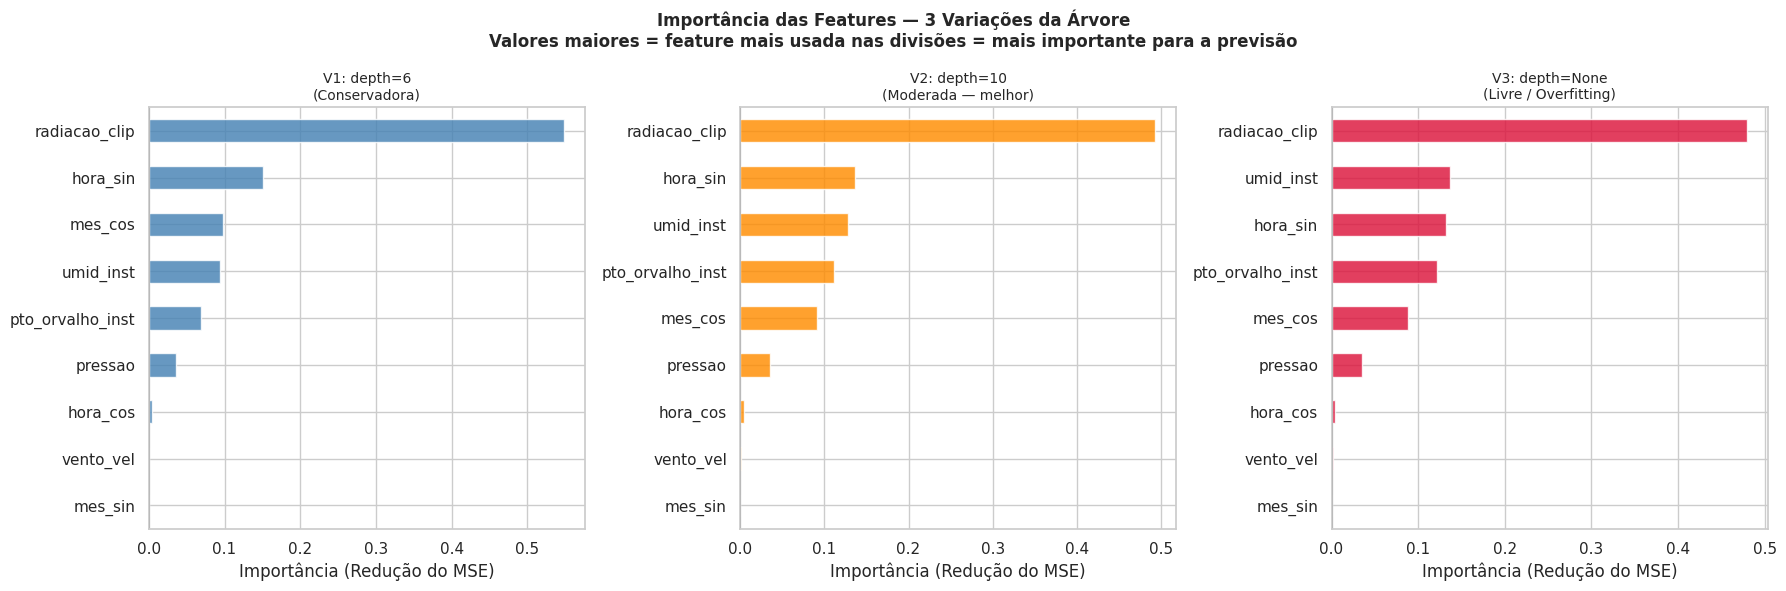

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

modelos_imp = [
    (dt_v1, 'V1: depth=6\n(Conservadora)', 'steelblue'),
    (dt_v2, 'V2: depth=10\n(Moderada — melhor)',  'darkorange'),
    (dt_v3, 'V3: depth=None\n(Livre / Overfitting)', 'crimson'),
]

for ax, (modelo, titulo, cor) in zip(axes, modelos_imp):
    imp = pd.Series(modelo.feature_importances_, index=features).sort_values(ascending=True)
    imp.plot(kind='barh', ax=ax, color=cor, edgecolor='white', alpha=0.82)
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel('Importância (Redução do MSE)')
    ax.axvline(0, color='black', linewidth=0.5)

plt.suptitle(
    'Importância das Features — 3 Variações da Árvore\n'
    'Valores maiores = feature mais usada nas divisões = mais importante para a previsão',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

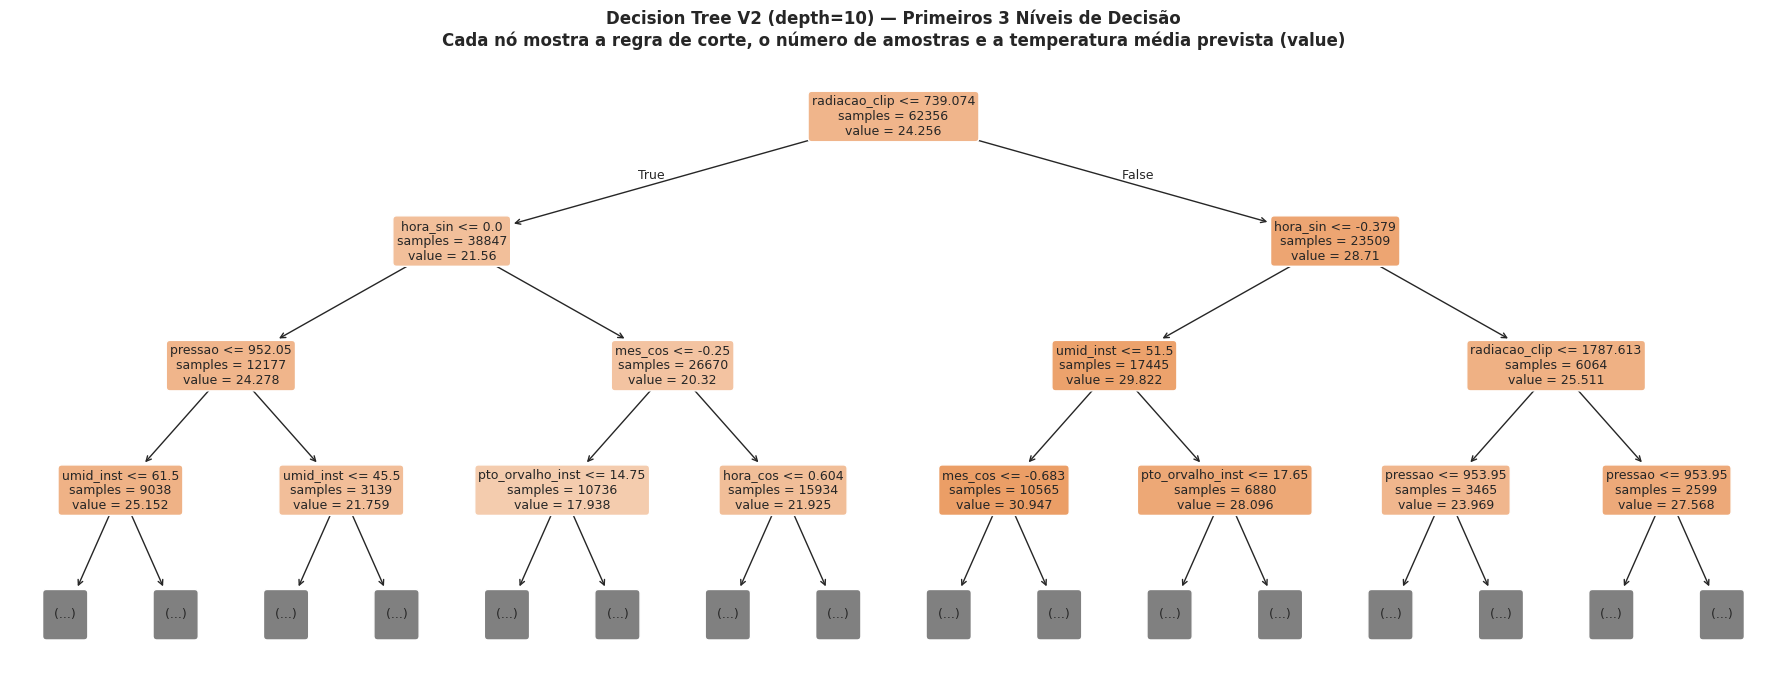

In [51]:
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(
    dt_v2, max_depth=3,
    feature_names=features,
    filled=True, rounded=True,
    fontsize=9, ax=ax, impurity=False
)
ax.set_title(
    'Decision Tree V2 (depth=10) — Primeiros 3 Níveis de Decisão\n'
    'Cada nó mostra a regra de corte, o número de amostras e a temperatura média prevista (value)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

---
## Comparação Final e Conclusão